In [3]:
import pandas as pd
import sqlite3

# carregar dataset
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# criar base de dados em memória
conn = sqlite3.connect(':memory:')

# guardar tabela
df.to_sql('churn_data', conn, index=False, if_exists='replace')

# ver primeiras linhas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


***EDA para explorar os dados e perceber o que fazer com eles***

In [4]:
pd.read_sql("""
SELECT *
FROM churn_data
LIMIT 10;
""", conn)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [5]:
pd.read_sql("""
SELECT Churn, COUNT(*) as total
FROM churn_data
GROUP BY Churn;
""", conn) # Verificar a diferença entre churn sim ou não, possível validar que há uma diferença mais ou menos 1 para 5

,Churn,total
0,No,5174
1,Yes,1869


In [6]:
pd.read_sql("""
SELECT
    Contract,
    COUNT(*) as total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as churned,
    ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) as churn_rate
FROM churn_data
GROUP BY Contract
ORDER BY churn_rate DESC;
""", conn)

,Contract,total_customers,churned,churn_rate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


We can see that the longer contracts have lower churn rates as the shorter contract (month to month) has the highest value. As the 42.72% is in a sample of 1655 clients, this is an extremel high number of losses (695 clients). We can then deduct that clients might not be compromised, onboarding might need to be reevaluated, retention techinques might need to improve. I suggest finding ways to improve the first fews months experience to incentivise longer contracts.  

In [7]:
pd.read_sql("""
SELECT *
FROM churn_data
WHERE TotalCharges = ' ';
""", conn) # checking for blanks and cleaning data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
1,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
2,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
3,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
4,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
5,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
6,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
7,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
8,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
9,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [8]:
pd.read_sql("""
SELECT tenure, COUNT(*)
FROM churn_data
WHERE TotalCharges = ' '
GROUP BY tenure;
""", conn) # Understand if the lines where the value is blank are new customers or if it's actually an error

,tenure,COUNT(*)
0,0,11


In [9]:
pd.read_sql("""
SELECT
    CAST(REPLACE(TotalCharges, ' ', '0') AS REAL) AS TotalCharges_clean
FROM churn_data;
""", conn) # After detecting that it is new customers, replaced the blanks with 0 as to maintain data integrity

,TotalCharges_clean
0,29.85
1,1889.50
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.50
7039,7362.90
7040,346.45
7041,306.60


In [10]:
pd.read_sql("""
SELECT
    PaymentMethod,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned,
    ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate
FROM churn_data
GROUP BY PaymentMethod
ORDER BY churn_rate DESC;
""", conn)

,PaymentMethod,total_customers,churned,churn_rate
0,Electronic check,2365,1071,45.29
1,Mailed check,1612,308,19.11
2,Bank transfer (automatic),1544,258,16.71
3,Credit card (automatic),1522,232,15.24


We can see that the payment method is strongly associated with churn. Customers using Electronic Check present the highest cancellation rate (45.29%), significantly higher than other payment methods. In contrast, automatic payment methods such as credit card (15.24%) and bank transfer (16.71%) show the lowest churn levels. This suggests that automatic payment methods are linked to higher customer retention, while Electronic Check represents the highest risk of customer loss and should be a priority for improvement.

In [11]:
pd.read_sql("""
SELECT
    CASE
        WHEN tenure <= 12 THEN '0-12 months'
        WHEN tenure <= 24 THEN '1-2 years'
        WHEN tenure <= 48 THEN '2-4 years'
        ELSE '4+ years'
    END AS tenure_group,

    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned,
    ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate

FROM churn_data
GROUP BY tenure_group
ORDER BY churn_rate DESC;
""", conn)

,tenure_group,total_customers,churned,churn_rate
0,0-12 months,2186,1037,47.44
1,1-2 years,1024,294,28.71
2,2-4 years,1594,325,20.39
3,4+ years,2239,213,9.51


We can see that almost 50% of customers churn in the first year. This suggests that it is highly needed to improve the retention techniques and onboarding within the fist year. We can also see that after 2+ years, only around 20% chruns, which is a significant decline from the first 47,44%.

In [12]:
pd.read_sql("""
SELECT
    customerID,
    tenure,
    Contract,
    MonthlyCharges,
    Churn,

    CASE
        WHEN Contract = 'Month-to-month'
             AND tenure <= 12
             AND MonthlyCharges >= 70
        THEN 'HIGH RISK'

        WHEN Contract = 'Month-to-month'
        THEN 'MEDIUM RISK'

        ELSE 'LOW RISK'
    END AS risk_segment

FROM churn_data;
""", conn) # Creating a system for client segmentation based on behaviour and client value

,customerID,tenure,Contract,MonthlyCharges,Churn,risk_segment
0,7590-VHVEG,1,Month-to-month,29.85,No,MEDIUM RISK
1,5575-GNVDE,34,One year,56.95,No,LOW RISK
2,3668-QPYBK,2,Month-to-month,53.85,Yes,MEDIUM RISK
3,7795-CFOCW,45,One year,42.30,No,LOW RISK
4,9237-HQITU,2,Month-to-month,70.70,Yes,HIGH RISK
...,...,...,...,...,...,...
7038,6840-RESVB,24,One year,84.80,No,LOW RISK
7039,2234-XADUH,72,One year,103.20,No,LOW RISK
7040,4801-JZAZL,11,Month-to-month,29.60,No,MEDIUM RISK
7041,8361-LTMKD,4,Month-to-month,74.40,Yes,HIGH RISK


In [13]:
pd.read_sql("""
SELECT
    Churn,
    SUM(MonthlyCharges) AS total_revenue
FROM churn_data
GROUP BY Churn;
""", conn) # Calculating the money lost by churn

,Churn,total_revenue
0,No,316985.75
1,Yes,139130.85


In [14]:
pd.read_sql("""
SELECT
    SUM(MonthlyCharges) AS revenue_lost
FROM churn_data
WHERE Churn = 'Yes';
""", conn) # Revenue lost

,revenue_lost
0,139130.85


In [15]:
pd.read_sql("""
SELECT
    CASE
        WHEN Contract = 'Month-to-month'
             AND tenure <= 12
             AND MonthlyCharges >= 70
        THEN 'HIGH RISK'

        WHEN Contract = 'Month-to-month'
        THEN 'MEDIUM RISK'

        ELSE 'LOW RISK'
    END AS risk_segment,

    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN MonthlyCharges ELSE 0 END) AS revenue_lost

FROM churn_data
GROUP BY risk_segment;
""", conn)

,risk_segment,total_customers,revenue_lost
0,HIGH RISK,860,49876.10
1,LOW RISK,3168,18283.75
2,MEDIUM RISK,3015,70971.00


We identfied that High Risk customers contribute highly to Revenue Lost, highlighting the critical need to change retention policy.

In [16]:
pd.read_sql("""
SELECT
    Contract,
    PaymentMethod,
    AVG(MonthlyCharges) AS avg_spend,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers
FROM churn_data
GROUP BY Contract, PaymentMethod
ORDER BY churned_customers DESC;
""", conn)

,Contract,PaymentMethod,avg_spend,churned_customers
0,Month-to-month,Electronic check,74.989486,994
1,Month-to-month,Mailed check,46.050056,282
2,Month-to-month,Bank transfer (automatic),69.085399,201
3,Month-to-month,Credit card (automatic),67.678821,178
4,One year,Electronic check,79.095245,64
5,One year,Credit card (automatic),67.972362,41
6,One year,Bank transfer (automatic),67.484143,38
7,One year,Mailed check,44.306380,23
8,Two year,Bank transfer (automatic),65.013918,19
9,Two year,Credit card (automatic),64.422117,13


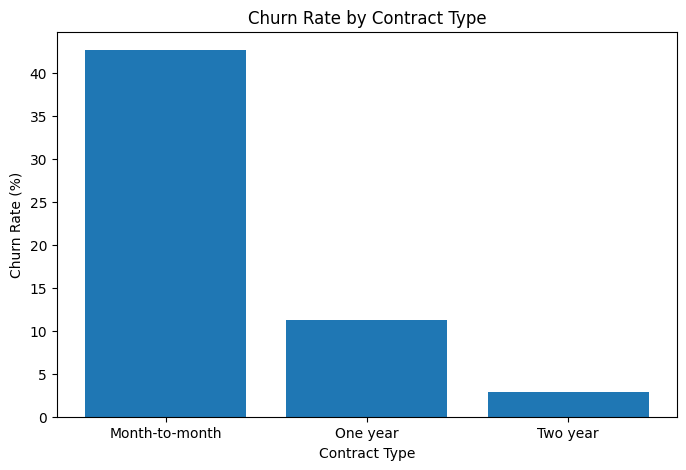

In [20]:
import matplotlib.pyplot as plt

data = pd.read_sql("""
SELECT
    Contract,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned
FROM churn_data
GROUP BY Contract
""", conn)

data['churn_rate'] = data['churned'] / data['total_customers'] * 100
data = data.sort_values('churn_rate', ascending=False)

plt.figure(figsize=(8,5))

plt.bar(data['Contract'], data['churn_rate'])

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

plt.show()